# Fit a spectrum or two with GIOP and BING

# PACE v3

## https://oceancolor.gsfc.nasa.gov/data/reprocessing/V3.0/pace/

In [1]:
# imports
from importlib import reload
import os
import numpy as np

from matplotlib import pyplot as plt

import xarray
import pandas

from ocpy.pace import io as pace_io
from ocpy.utils import plotting

from bing.parameters import standard
from bing.models import utils as model_utils
from bing.models import bbnw
from bing.priors import priors as bing_priors
from bing.fitting import inference as bing_inf
from bing import evaluate
from bing.fitting import chisq_fit
from bing import plotting as bing_plotting

# Locals
from grab_pace_granules import load_from_json
import fitting as m_fitting
import grab_pace_granules

# Load the data

## Matched

In [2]:
match_file = 'matched_argo_bgc_profiles_bbp.csv'
# Load up Argo profiles, already matched to PACE
matched = pandas.read_csv(match_file)

# Load up PACE granules
granules, pace = load_from_json('PACE_50clouds.json')


In [3]:
idx = 0
imatched = matched.iloc[idx]
imatched

cruise                                                       1902368
filename                                                1902368QC.nc
profile                                                           13
lat                                                           56.348
lon                                                         -147.356
time                             2024-07-09 04:35:00.000002048+00:00
solar_angle                                                13.134825
pace_ids           PACE_OCI_L2_AOP_PACE_OCI.20240708T202028.L2.OC...
closest_id         PACE_OCI_L2_AOP_PACE_OCI.20240708T202028.L2.OC...
closest_file              PACE_OCI.20240708T202028.L2.OC_AOP.V3_0.nc
closest_dist_km                                           671.392674
closest_time                        2024-07-08 20:22:57.500000+00:00
Bnw                                                         0.001467
Bnw_std                                                     0.000453
Bnw_lsig                          

## Load FITS

In [4]:
fits_file = m_fitting.set_outfile(imatched)
fits = np.load(fits_file)
list(fits.keys())

['chains',
 'LM',
 'wave',
 'Rrs',
 'Rrs_sig',
 'Rrs_idx',
 'lon',
 'lat',
 'dist',
 'med',
 'p14',
 'p86',
 'model_names']

## Unpack

In [5]:
wave = fits['wave'][0] 
Rrs = fits['Rrs'][0]
Rrs_sig =fits['Rrs_sig'][0]

In [6]:
i440 = np.argmin(np.abs(wave-440.))
i555 = np.argmin(np.abs(wave-555.))

# Plot 

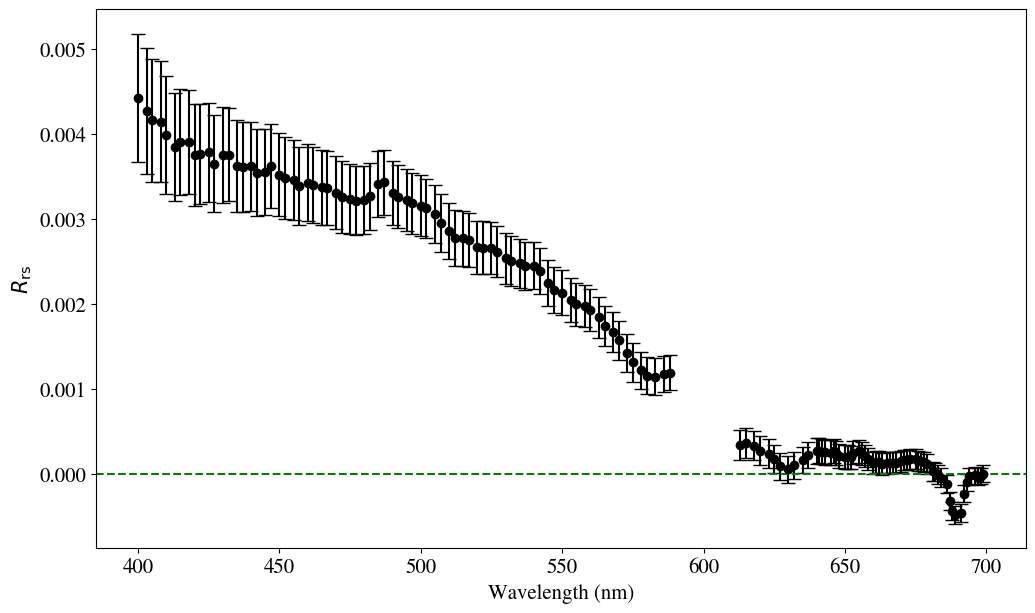

In [7]:
fig = plt.figure(figsize=(12,7))
ax = plt.gca()
#
ax.errorbar(wave, Rrs, yerr=Rrs_sig, color='k',  fmt='o', capsize=5) 
#
#ax.set_yscale('log')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{\rm rs}$')
ax.axhline(0., color='g', ls='--')
#
plotting.set_fontsize(ax, 15.)
#
plt.show()

# Fit one

## Parse out the data

In [17]:
iwave = wave
ispec = Rrs
isig = Rrs_sig

## Parameters

In [18]:
p = standard.expb_pow()
p

BING20_tuple(model_names=['ExpBricaud', 'Pow'], scl_noise='PACE', wv_min=400.0, wv_max=700.0, satellite='PACE', add_noise=False, apriors=[{'flavor': 'log_uniform', 'pmin': -6, 'pmax': 5}, {'flavor': 'uniform', 'pmin': 0.01, 'pmax': 0.02}, {'flavor': 'log_uniform', 'pmin': -6, 'pmax': 5}], bpriors=[{'flavor': 'log_uniform', 'pmin': -6, 'pmax': 5}, {'flavor': 'uniform', 'pmin': 0.0, 'pmax': 2.0}], othera_priors=None, set_Sdg=False, sSdg=0.002, beta=None, nMC=None, nsteps=40000, nburn=1000)

## Models

In [19]:
# Models
models = model_utils.init(p.model_names, iwave)

In [20]:
models

[<aNWModel: ExpBricaud, nparam=3>, <bbNWModel: Pow, nparam=2>]

## Priors

In [21]:
bing_priors.set_standard_priors(models, p)

## LM first

In [22]:
low_bounds, high_bounds = [], []
low_bounds += [item['pmin'] for item in p.apriors]
low_bounds += [item['pmin'] for item in p.bpriors]
high_bounds += [item['pmax'] for item in p.apriors]
high_bounds += [item['pmax'] for item in p.bpriors]
#
bounds = (np.array(low_bounds), np.array(high_bounds))

In [23]:
p0 = [-1, 0.015, -1, -1, 1.5]
items = [(ispec, isig**2, p0, 0)]
ans, cov, idx = chisq_fit.fit(items[0], models, bounds=bounds)

### Plot

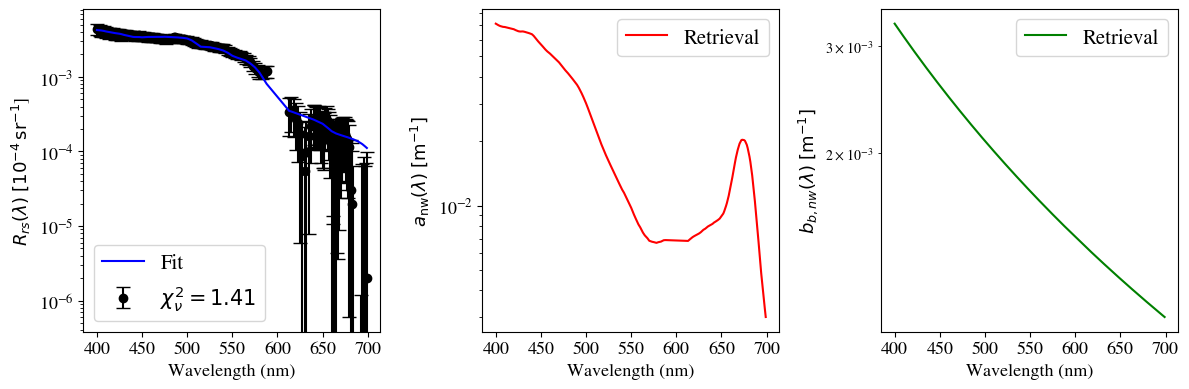

In [24]:
Chl = 10**ans[-1] / 0.05582
bing_plotting.show_fits(models, ans,  Chl, None,
                figsize=(12,4),
                fontsize=13.,
                Rrs_true=dict(wave=models[0].wave, spec=ispec, var=isig**2),
                  log_abb=True,
                )
plt.show()

## Initialize the MCMC

In [25]:
pdict = bing_inf.init_mcmc(models, nsteps=p.nsteps, nburn=p.nburn)

In [26]:
pdict['Chl'] = np.array([0.1 / 0.05582])
pdict['Y'] = None

## Items

In [27]:
#p0 = [-1, 0.015, -1, -1, 1.5]
p0 = ans.tolist()
items = [(ispec, isig**2, p0, 0)]

## Fit me

In [28]:
chains, idx = bing_inf.fit_one(
        items[0], models=models, pdict=pdict, chains_only=True)

idx=0
Running burn-in


  0%|                                                 | 0/1000 [00:00<?, ?it/s]/home/xavier/miniconda3/envs/ocean/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 1141.67it/s]


Running full model


100%|███████████████████████████████████| 40000/40000 [00:40<00:00, 981.72it/s]


In [29]:
chains.shape

(40000, 16, 5)

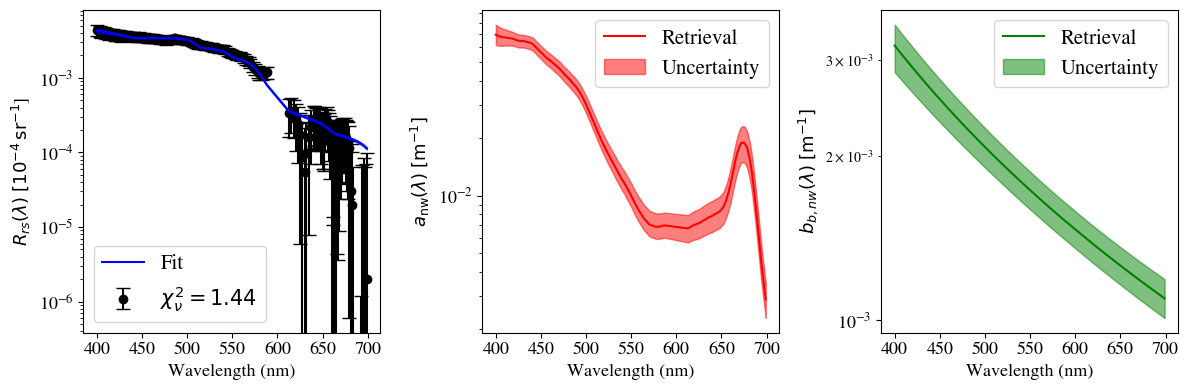

In [30]:
reload(bing_plotting)
bing_plotting.show_fits(models, chains,  None, None,
                figsize=(12,4),
                fontsize=13.,
                Rrs_true=dict(wave=models[0].wave, spec=ispec, var=isig**2),
                        log_abb=True,
                   #Rrs_true=dict(wave=df_lee.wave, spec=gordon_Rrs_1),
                #anw_true=anw_dict, bbnw_true=bbnw_dict,
                )
plt.show()

# GIOP

In [8]:
p_giop = standard.giop()

In [11]:
reload(bbnw)
reload(model_utils)
models_giop = model_utils.init(p_giop.model_names, iwave)
models_giop

[<aNWModel: GIOP, nparam=2>, <bbNWModel: Lee, nparam=1>]

## Chl (am using the results above instead of OC)

In [31]:
ans

array([-1.35949506,  0.02      , -1.35730502, -2.83804007,  2.        ])

In [32]:
models_giop[0].set_aph(10**ans[2]/0.05582)

## $Y$

In [46]:
models_giop[1].compute_Y(Rrs[i440], Rrs[i555])
models_giop[1].Y

np.float32(1.683451)

In [34]:
low_bounds, high_bounds = [], []
low_bounds += [item['pmin'] for item in p_giop.apriors]
low_bounds += [item['pmin'] for item in p_giop.bpriors]
high_bounds += [item['pmax'] for item in p_giop.apriors]
high_bounds += [item['pmax'] for item in p_giop.bpriors]
#
bounds = (np.array(low_bounds), np.array(high_bounds))
bounds

(array([-6, -6, -6]), array([5, 5, 5]))

In [35]:
p0 = [-1, -1, -1]
#p0 = ans.tolist()
items = [(ispec, isig**2, p0, 0)]
ans_giop, cov_giop, idx = chisq_fit.fit(items[0], models_giop, bounds=bounds)
ans_giop

array([-1.39863623, -1.38396383, -2.82830539])

In [45]:
models_giop[1].Y

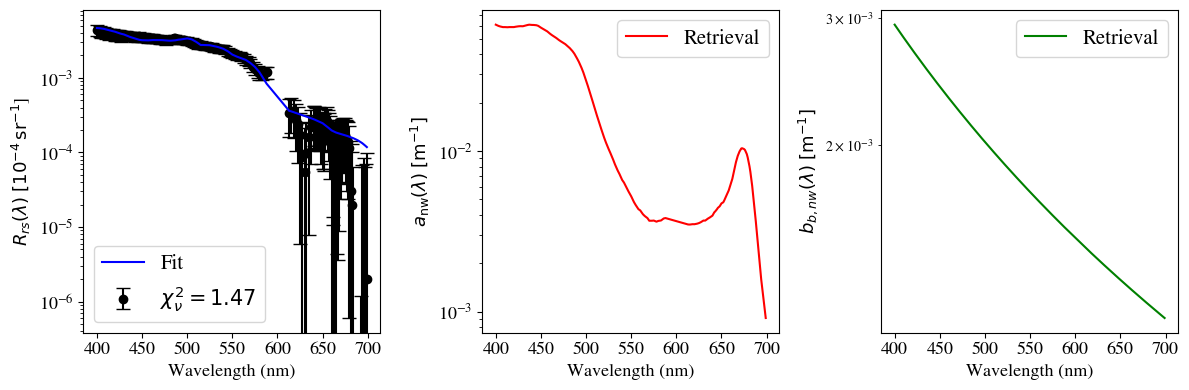

In [47]:
Chl = 10**ans_giop[-1] / 0.05582
bing_plotting.show_fits(models_giop, ans_giop,  Chl, models_giop[1].Y,
                figsize=(12,4),
                fontsize=13.,
                Rrs_true=dict(wave=models_giop[0].wave, spec=ispec, var=isig**2),
                  log_abb=True,
                )
plt.show()

# Compare the values

## MCMC

In [59]:
models[1].pivot

600.0

In [51]:
stats = evaluate.calc_stats(chains)
stats

{'names': ['p0', 'p1', 'p2', 'p3', 'p4'],
 'med': array([-1.3577545 ,  0.01823911, -1.3862263 , -2.8337057 ,  1.9302714 ],
       dtype=float32),
 'p14': array([-1.43743   ,  0.01603696, -1.4463917 , -2.8563688 ,  1.8067081 ],
       dtype=float32),
 'p86': array([-1.2859979 ,  0.01956513, -1.3353548 , -2.8117695 ,  1.9846373 ],
       dtype=float32)}

In [64]:
10**stats['med'][-2]

np.float32(0.0014665414)

## GIOP LM

In [56]:
models_giop[1].pivot

600.0

In [63]:
# bbp at 600nm
10**ans_giop[-1]

np.float64(0.0014848911053411823)

## And PACE?

In [62]:
imatched.GIOP_bbp_700

np.float64(0.00148122664541)

----